# L2 · Notebook 04 — UAV 3D：Bellman 评估的维度爆炸演示

**对应教材**：`miclDRL/chapters/part2-ch02-bellman-equation.tex`  
**对应 PPT**：`L2-bellman-equation-cn/`

## 教学目标

把 Notebook 01-03 在 5×5 网格上做的 Bellman 评估，**整套搬到 UAV 3D 环境**上：

1. 数学**完全不变**：仍然是 $\mathbf{v}^\pi=(I-\gamma P^\pi)^{-1}\mathbf{r}^\pi$ 或迭代 $\mathbf{v}_{k+1}=\mathbf{r}^\pi+\gamma P^\pi\mathbf{v}_k$。
2. 但 **$|\mathcal{S}|$ 从 25 跳到 4096**（约 $164\times$）——直接体会"表格 RL 为何撑不到深度 RL"。
3. 测一下 4096×4096 的线性解与迭代解各要多久，**外推 $|\mathcal{S}|$ 再翻倍后的时长**——为 L8 函数逼近铺垫。

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from shared.uav_grid import UAVGrid3D, UAVConfig
from shared.grid_world import GridWorld, GridConfig
from shared.plotting import setup_chinese_font

setup_chinese_font()
os.makedirs('figures', exist_ok=True)
rng = np.random.default_rng(0)

## 1. 环境对照：5×5 grid vs UAV 3D

状态空间维度直接决定 $P^\pi$ 的大小（$|\mathcal{S}|\times|\mathcal{S}|$）。把两者并排打印。

In [2]:
grid = GridWorld(GridConfig())
uav = UAVGrid3D()

print(f"5×5 GridWorld: |S| = {grid.n_states:4d}, |A| = {grid.n_actions}, actions = {grid.actions}")
print(f"UAVGrid3D    : |S| = {uav.n_states:4d}, |A| = {uav.n_actions}, actions = {uav.actions}")
print(f"               维度比 = {uav.n_states / grid.n_states:.1f}×")
print(f"               UAV 状态 = (row, col, alt, battery), 网格 {uav.cfg.n_rows}×{uav.cfg.n_cols}×{uav.cfg.n_alts}, 电量 0..{uav.cfg.n_battery-1}")

5×5 GridWorld: |S| =   25, |A| = 5, actions = ['up', 'down', 'left', 'right', 'stay']
UAVGrid3D    : |S| = 4096, |A| = 7, actions = ['north', 'south', 'west', 'east', 'hover', 'ascend', 'descend']
               维度比 = 163.8×
               UAV 状态 = (row, col, alt, battery), 网格 8×8×4, 电量 0..15


## 2. 选定策略 $\pi$，构造 $P^\pi$ 与 $\mathbf{r}^\pi$

用一个**朴素降落策略**：所有状态都执行 `descend`（一路下降直到着陆 / 撞地 / 电量耗尽）。这不是最优，但便于人工核对——着陆点附近期望回报应明显高，撞建筑物处应低。

In [3]:
policy = {s: 'descend' for s in uav.all_states()}

t0 = time.time()
P_pi = uav.transition_matrix(policy)
r_pi = uav.reward_vector(policy)
t_build = time.time() - t0

print(f"P^π shape   = {P_pi.shape}")
print(f"r^π shape   = {r_pi.shape}")
print(f"行和检查    : min={P_pi.sum(axis=1).min():.6f}, max={P_pi.sum(axis=1).max():.6f}  (确定性 MDP 应全 = 1)")
print(f"构造 P/r 用时: {t_build:.3f} s")

P^π shape   = (4096, 4096)
r^π shape   = (4096,)
行和检查    : min=1.000000, max=1.000000  (确定性 MDP 应全 = 1)
构造 P/r 用时: 0.066 s


## 3. 闭式解 $\mathbf{v}^\pi=(I-\gamma P^\pi)^{-1}\mathbf{r}^\pi$

对 4096×4096 矩阵 LU 分解，复杂度 $O(|\mathcal{S}|^3)\approx 6.9\times 10^{10}$ 浮点运算——CPU 上仍能秒级跑完，但**再翻一倍就是 8× 的时间**。

In [4]:
gamma = uav.cfg.gamma
I = np.eye(uav.n_states)

t0 = time.time()
v_pi_linear = np.linalg.solve(I - gamma * P_pi, r_pi)
t_linear = time.time() - t0

residual = np.max(np.abs((I - gamma * P_pi) @ v_pi_linear - r_pi))
print(f"闭式解用时   : {t_linear:.2f} s")
print(f"Bellman 残差 : ||·||_∞ = {residual:.2e}")
print(f"v^π 范围     : [{v_pi_linear.min():.3f}, {v_pi_linear.max():.3f}]")

闭式解用时   : 3.48 s
Bellman 残差 : ||·||_∞ = 8.88e-16
v^π 范围     : [-10.000, 1.000]


## 4. 迭代评估 $\mathbf{v}_{k+1}=\mathbf{r}^\pi+\gamma P^\pi \mathbf{v}_k$

复杂度 $O(K\cdot|\mathcal{S}|^2)$，$K$ 由 $\gamma$ 决定（$\gamma=0.9$ 时数百轮内 1e-9 收敛）。

In [5]:
V = np.zeros(uav.n_states)
residuals = []
t0 = time.time()
for k in range(2000):
    V_new = r_pi + gamma * P_pi @ V
    delta = np.max(np.abs(V_new - V))
    residuals.append(delta)
    V = V_new
    if delta < 1e-9:
        break
t_iter = time.time() - t0

print(f"迭代评估用时 : {t_iter:.2f} s,  收敛轮数 K = {k+1}")
print(f"与闭式解最大偏差: {np.max(np.abs(V - v_pi_linear)):.2e}")
print(f"理论 γ^K = {gamma**(k+1):.2e}  (压缩映射给出的上界)")

迭代评估用时 : 5.14 s,  收敛轮数 K = 198
与闭式解最大偏差: 8.71e-09
理论 γ^K = 8.71e-10  (压缩映射给出的上界)


## 5. 切片可视化：$V^\pi$ 在 (row, col) 平面

UAV 状态是 4 维 $(r,c,a,b)$，无法画全。**固定** altitude $a=2$、battery $b=10$，看剩余的 row-col 切片——直观验证：靠近 target $(6,6,0)$ 的状态价值高，靠近建筑物的低。

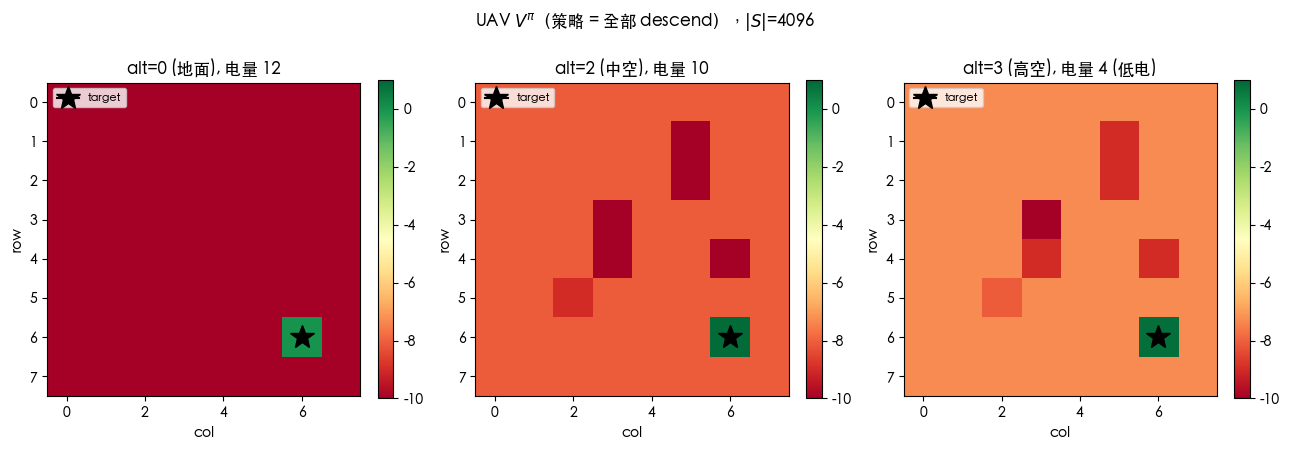

In [6]:
def slice_v(v, alt_fix, bat_fix):
    grid = np.full((uav.cfg.n_rows, uav.cfg.n_cols), np.nan)
    for (r, c, a, b), idx in uav._state_to_idx.items():
        if a == alt_fix and b == bat_fix:
            grid[r, c] = v[idx]
    return grid

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (alt, bat, title) in zip(
    axes,
    [(0, 12, 'alt=0 (地面), 电量 12'),
     (2, 10, 'alt=2 (中空), 电量 10'),
     (3,  4, 'alt=3 (高空), 电量 4 (低电)')]
):
    g = slice_v(v_pi_linear, alt, bat)
    im = ax.imshow(g, cmap='RdYlGn', vmin=v_pi_linear.min(), vmax=v_pi_linear.max())
    ax.set_title(title)
    ax.set_xlabel('col'); ax.set_ylabel('row')
    tr, tc, _ = uav.cfg.target
    ax.plot(tc, tr, marker='*', color='black', markersize=18, label='target')
    ax.legend(loc='upper left', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f'UAV $V^\\pi$（策略 = 全部 descend），$|S|$={uav.n_states}', y=1.02)
plt.tight_layout()
plt.savefig('figures/uav_v_pi_slices.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. 维度外推：什么时候表格 Bellman 撑不住？

闭式解是 $O(|\mathcal{S}|^3)$ 浮点数 $+$ $O(|\mathcal{S}|^2)$ 内存。
电量 / 高度档位再翻倍，时长和内存的增长都不可接受——**这是 L8 函数逼近（线性 / 神经网络）登场的直接动机**。

下面用现有 4096 状态的实测时长，按 $O(n^3)$ 外推。

In [7]:
base_n = uav.n_states
base_t = t_linear

scenarios = [
    ('当前 (8×8×4×16)',         base_n,           1),
    ('电量 16→32',              base_n * 2,       2),
    ('alt 4→8 + 电量 16→32',    base_n * 4,       4),
    ('网格 8→16 + 电量 16→32',  base_n * 8,       8),
    ('全部翻倍 (16×16×8×32)',   base_n * 16,     16),
]

print(f"基准：|S|={base_n},  闭式解 {base_t:.2f}s,  P^π 内存 {(base_n**2 * 8 / 1e6):.1f} MB")
print()
print(f"{'场景':<28} {'|S|':>8} {'闭式解时长':>12} {'P^π 内存':>12}")
print('-' * 68)
for name, n, k in scenarios:
    t_pred = base_t * (n / base_n) ** 3
    mem_mb = n * n * 8 / 1e6
    print(f'{name:<28} {n:>8d} {t_pred:>10.2f}s   {mem_mb:>9.1f} MB')

print()
print('结论：|S| 一过 ~5万，CPU 闭式解就基本不可行；')
print('     |S| 一过 ~30万，连存 P^π 都吃满 16GB 内存。')
print('     → L8 起：用线性 / 神经网络逼近 v(s), 不再显式存 |S|×|S| 矩阵。')

基准：|S|=4096,  闭式解 3.48s,  P^π 内存 134.2 MB

场景                                |S|        闭式解时长       P^π 内存
--------------------------------------------------------------------
当前 (8×8×4×16)                    4096       3.48s       134.2 MB
电量 16→32                         8192      27.81s       536.9 MB
alt 4→8 + 电量 16→32              16384     222.51s      2147.5 MB
网格 8→16 + 电量 16→32              32768    1780.05s      8589.9 MB
全部翻倍 (16×16×8×32)               65536   14240.42s     34359.7 MB

结论：|S| 一过 ~5万，CPU 闭式解就基本不可行；
     |S| 一过 ~30万，连存 P^π 都吃满 16GB 内存。
     → L8 起：用线性 / 神经网络逼近 v(s), 不再显式存 |S|×|S| 矩阵。


## 7. 小结

| 论断 | 5×5 grid | UAV 3D |
|---|---|---|
| Bellman 方程矩阵形式 | $\mathbf{v}=\mathbf{r}+\gamma P\mathbf{v}$ | **同上，逐字不变** |
| $|\mathcal{S}|$ | 25 | **4096** |
| 闭式解 vs 迭代解一致 | 残差 < 1e-12 | 残差 ~ 1e-8 |
| 闭式解耗时 | $\approx 10^{-4}$ s | **秒级** |
| 切片可视化 | 一张 5×5 热图 | 需要选 (alt, battery) 切片 |
| 表格 RL 上限 | 远未触及 | **下一档翻倍就要 8× 时间** |

**承上启下**：本讲的所有结论（Bellman 方程的存在性、闭式可解性、迭代收敛 $\gamma^k$）在 UAV 4D 状态上原样成立——数学没变，**变的是工程可行性**。L4 用相同思路推到价值迭代 / 策略迭代；L8 起用函数逼近把 $|\mathcal{S}|$ 维矩阵替成 $d$ 维参数 $w$，把这一关绕过去。